In [ ]:
# Step 3: Data Preparation

import pandas as pd
from sklearn.model_selection import train_test_split

# d) Load/Read data
data_url = 'machine.csv'  # Replace with the actual path or URL to your dataset
df = pd.read_csv(data_url)
# e) Check the structure (data type) of the dataframe using the info() command
print(df.info())

# f) Check and convert variable types as needed
# The vendor name and model name attributes can be dropped
df.drop(columns=['Vendor Name', 'Model Name'], inplace=True)

# g) Check missing values
print(df.isnull().sum())

# h) Check the data spread using describe()
print(df.describe())

# i) Missing value treatment
# Let's fill the missing values with the mean for numeric columns
# Replace 'NaN' with the mean for columns containing numeric values
numeric_columns = df.select_dtypes(include='number').columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

# j) Outlier treatment (optional)
# If you want to perform outlier treatment, visualize boxplots and decide how to handle outliers

# k) Check the data and info() again
print(df.info())

# l) Transform the character variable to numeric using get_dummies()
# This step is not required in this case as there are no character variables left after dropping vendor name and model name.
# If you have categorical variables that need encoding, use pd.get_dummies() accordingly.

# Step 4: Split data into train and test data (70% Train and 30% Test)
# We'll use the 'PRP' column as the target variable and the rest as features

X = df.drop(columns=['PRP'])  # Features
y = df['PRP']  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Now, we have the data prepared and split into training and testing sets.
# Next, we can proceed with Step 5: Developing the Machine Learning Model (Linear Regression).

# Note: Since the target variable 'PRP' is integer-valued, linear regression seems like a good choice for this problem.



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Vendor Name  209 non-null    object
 1   Model Name   209 non-null    object
 2   MYCT         209 non-null    int64 
 3   MMIN         209 non-null    int64 
 4   MMAX         209 non-null    int64 
 5   CACH         209 non-null    int64 
 6   CHMIN        209 non-null    int64 
 7   CHMAX        209 non-null    int64 
 8   PRP          209 non-null    int64 
 9   ERP          209 non-null    int64 
dtypes: int64(8), object(2)
memory usage: 16.5+ KB
None
MYCT     0
MMIN     0
MMAX     0
CACH     0
CHMIN    0
CHMAX    0
PRP      0
ERP      0
dtype: int64
              MYCT          MMIN          MMAX        CACH       CHMIN  \
count   209.000000    209.000000    209.000000  209.000000  209.000000   
mean    203.822967   2867.980861  11796.153110   25.205742    4.698565   
std     260.262926   387

In [ ]:
from sklearn.model_selection import cross_val_predict

# Create a Linear Regression model
model = LinearRegression()

# Step 6: Train the model using the training data
model.fit(X_train, y_train)

# Step 7: Test the model using the test data
y_pred = model.predict(X_test)

# Step 8: Evaluate the model using metrics for Linear Regression
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R-squared (R2) Score:", r2)

# Step 9: Validation of the Model (Cross-Validation)
# Perform Cross-validation with 5 folds
cv_predictions = cross_val_predict(model, X_train, y_train, cv=5)

# Calculate the MSE using the cross-validated predictions and the true target values
cv_mse = mean_squared_error(y_train, cv_predictions)

print("Cross-Validation Mean Squared Error (MSE):", cv_mse)


Mean Squared Error (MSE): 4424.692886550784
R-squared (R2) Score: 0.9227273654755863
Cross-Validation Mean Squared Error (MSE): 1467.0276575517678


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 4: Split data into X (predictors) and Y (predicted)
X = df.drop(columns=['PRP'])
y = df['PRP']

# Step 5: Split data into test and train datasets (90/10 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Step 6: Train the model using Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Step 7: Scoring on the train dataset (using cross-validation)
# Perform Cross-validation with 10 folds
cv_predictions = cross_val_predict(model, X_train, y_train, cv=10)

# Calculate the MSE using the cross-validated predictions and the true target values
cv_mse = mean_squared_error(y_train, cv_predictions)

# Calculate R-squared using the cross-validated predictions and the true target values
cv_r2 = r2_score(y_train, cv_predictions)

print("Cross-Validation Mean Squared Error (MSE):", cv_mse)
print("Cross-Validation R-squared (R2) Score:", cv_r2)


Cross-Validation Mean Squared Error (MSE): 2387.5654569693656
Cross-Validation R-squared (R2) Score: 0.871179265542323


Cross-Validation Mean Squared Error (MSE): 2387.5654569693656
Cross-Validation R-squared (R2) Score: 0.871179265542323


<ipython-input-13-3b1231501ea3>:40: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(2, 4, idx + 1)


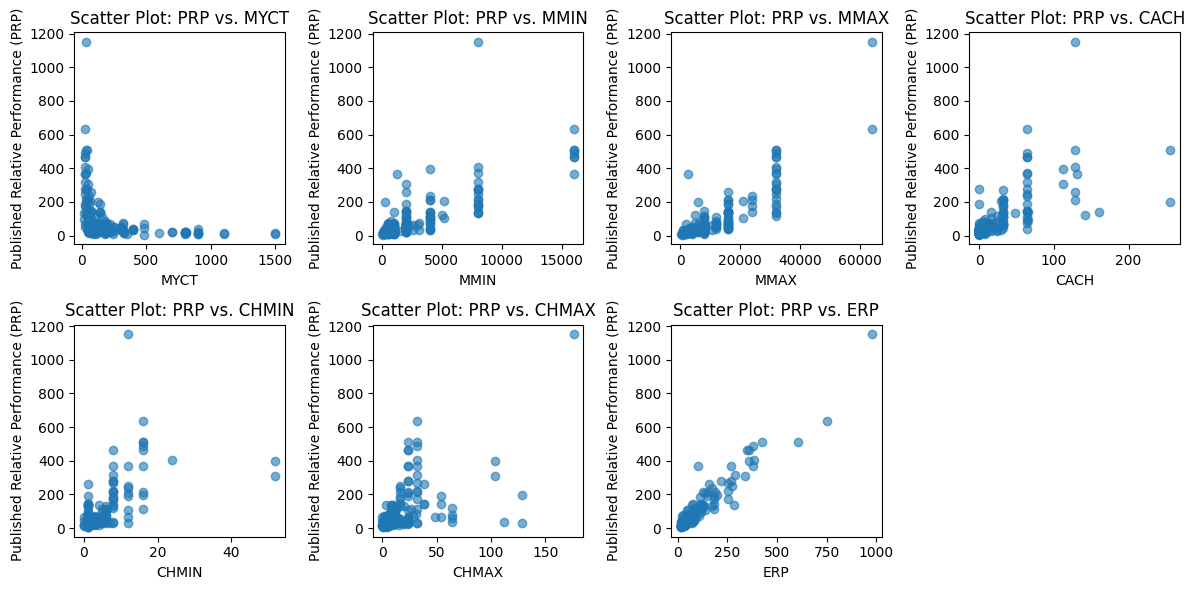

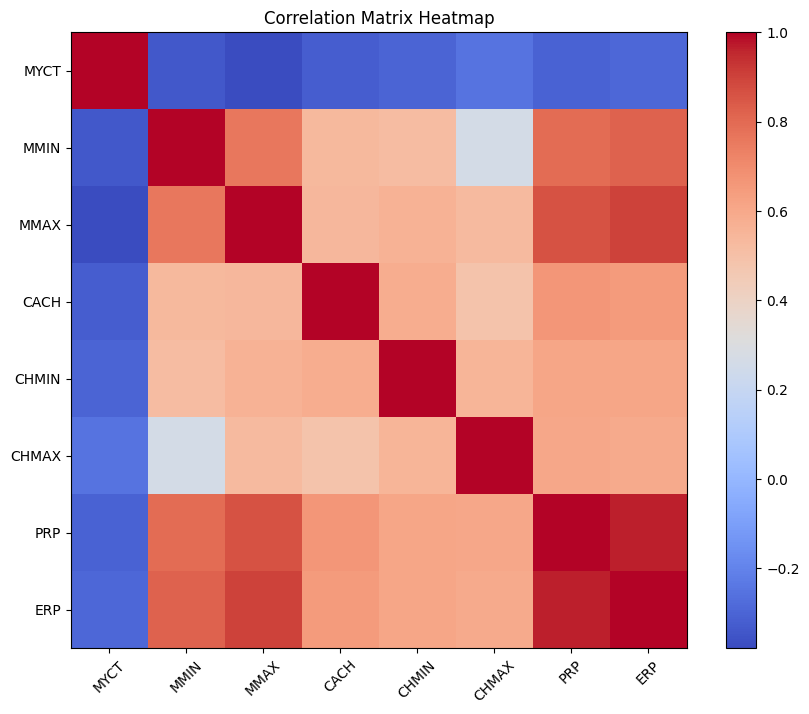

Summary Statistics:
              MYCT          MMIN          MMAX        CACH       CHMIN  \
count   209.000000    209.000000    209.000000  209.000000  209.000000   
mean    203.822967   2867.980861  11796.153110   25.205742    4.698565   
std     260.262926   3878.742758  11726.564377   40.628722    6.816274   
min      17.000000     64.000000     64.000000    0.000000    0.000000   
25%      50.000000    768.000000   4000.000000    0.000000    1.000000   
50%     110.000000   2000.000000   8000.000000    8.000000    2.000000   
75%     225.000000   4000.000000  16000.000000   32.000000    6.000000   
max    1500.000000  32000.000000  64000.000000  256.000000   52.000000   

            CHMAX          PRP          ERP  
count  209.000000   209.000000   209.000000  
mean    18.267943   105.622010    99.330144  
std     25.997318   160.830733   154.757102  
min      0.000000     6.000000    15.000000  
25%      5.000000    27.000000    28.000000  
50%      8.000000    50.000000    45.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Step 4: Split data into X (predictors) and Y (predicted)
X = df.drop(columns=['PRP'])
y = df['PRP']

# Step 5: Split data into test and train datasets (90/10 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Step 6: Train the model using Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Step 7: Scoring on the train dataset (using cross-validation)
# Perform Cross-validation with 10 folds
cv_predictions = cross_val_predict(model, X_train, y_train, cv=10)

# Calculate the MSE using the cross-validated predictions and the true target values
cv_mse = mean_squared_error(y_train, cv_predictions)

# Calculate R-squared using the cross-validated predictions and the true target values
cv_r2 = r2_score(y_train, cv_predictions)

print("Cross-Validation Mean Squared Error (MSE):", cv_mse)
print("Cross-Validation R-squared (R2) Score:", cv_r2)

# Data Visualization and Statistics
# Section 1: Data Distribution and Histogram of the target variable (PRP)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(y, bins=20, edgecolor='k', color='skyblue')
plt.xlabel('Published Relative Performance (PRP)')
plt.ylabel('Frequency')
plt.title('Distribution of Published Relative Performance (PRP)')

# Section 2: Scatter plots of PRP vs. each predictor variable
for idx, col in enumerate(X_train.columns):
    plt.subplot(2, 4, idx + 1)
    plt.scatter(X_train[col], y_train, alpha=0.6)
    plt.xlabel(col)
    plt.ylabel('Published Relative Performance (PRP)')
    plt.title(f'Scatter Plot: PRP vs. {col}')

plt.tight_layout()
plt.show()

# Section 3: Correlation matrix heatmap
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(correlation_matrix)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix)), correlation_matrix.columns)
plt.title('Correlation Matrix Heatmap')
plt.show()

# Section 4: Summary statistics of the dataset
summary_stats = df.describe()
print("Summary Statistics:")
print(summary_stats)

# Section 5: Additional Statistics (optional)
mean_prp = np.mean(df['PRP'])
median_prp = np.median(df['PRP'])
std_prp = np.std(df['PRP'])

print("Mean of PRP:", mean_prp)
print("Median of PRP:", median_prp)
print("Standard Deviation of PRP:", std_prp)

# Section 6: Linear Regression - Model Fitted (Min-Max Normalized Data)
# Min-Max normalization of the predictors
scaler = MinMaxScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

# Train the model on normalized data
model_normalized = LinearRegression()
model_normalized.fit(X_train_normalized, y_train)

# Evaluate the model on the normalized test data
y_pred_normalized = model_normalized.predict(X_test_normalized)
mse_normalized = mean_squared_error(y_test, y_pred_normalized)
r2_normalized = r2_score(y_test, y_pred_normalized)

print("Mean Squared Error (MSE) on Min-Max Normalized Test Data:", mse_normalized)
print("R-squared (R2) Score on Min-Max Normalized Test Data:", r2_normalized)

# Section 7: Linear Regression - Model Fitted (Z-score Standardized Data)
# Z-score standardization of the predictors
scaler = StandardScaler()
X_train_standardized = scaler.fit_transform(X_train)
X_test_standardized = scaler.transform(X_test)

# Train the model on standardized data
model_standardized = LinearRegression()
model_standardized.fit(X_train_standardized, y_train)

# Evaluate the model on the standardized test data
y_pred_standardized = model_standardized.predict(X_test_standardized)
mse_standardized = mean_squared_error(y_test, y_pred_standardized)
r2_standardized = r2_score(y_test, y_pred_standardized)

print("Mean Squared Error (MSE) on Z-score Standardized Test Data:", mse_standardized)
print("R-squared (R2) Score on Z-score Standardized Test Data:", r2_standardized)


Cross-Validation Mean Squared Error (MSE): 2387.5654569693656
Cross-Validation R-squared (R2) Score: 0.871179265542323


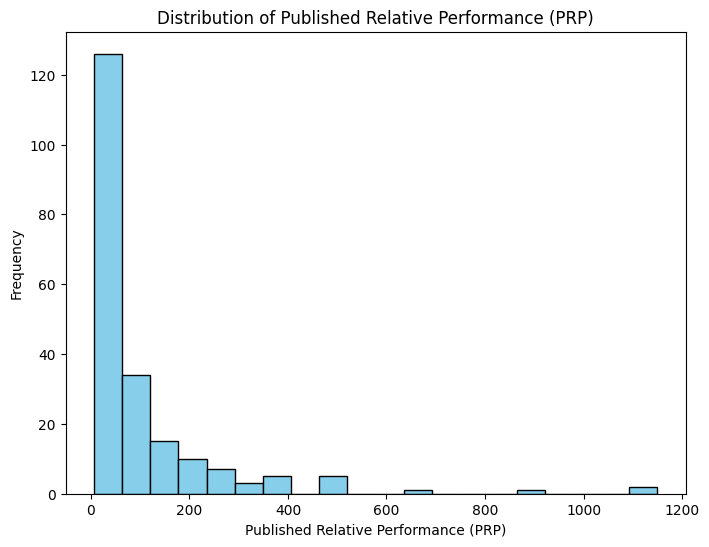

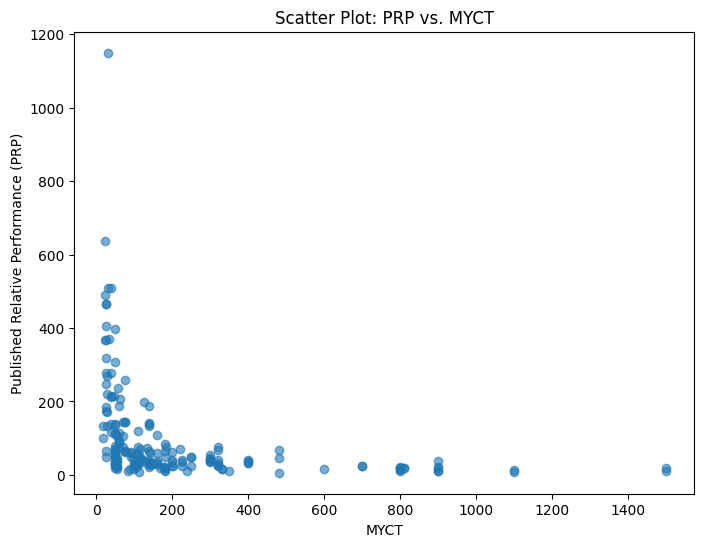

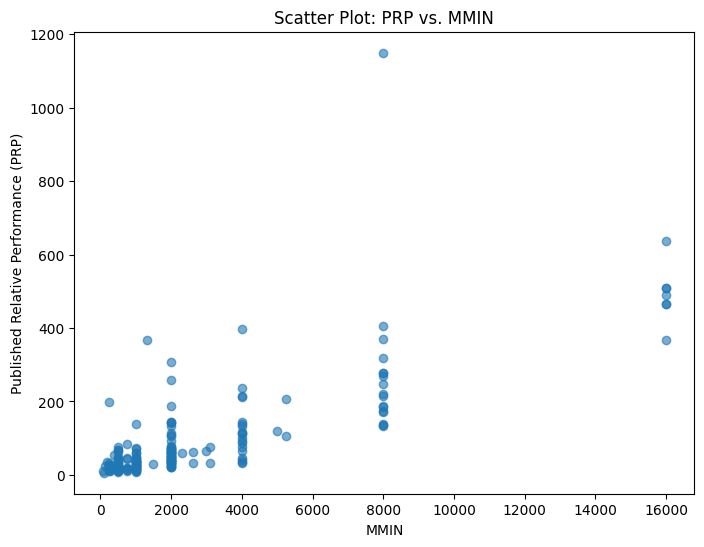

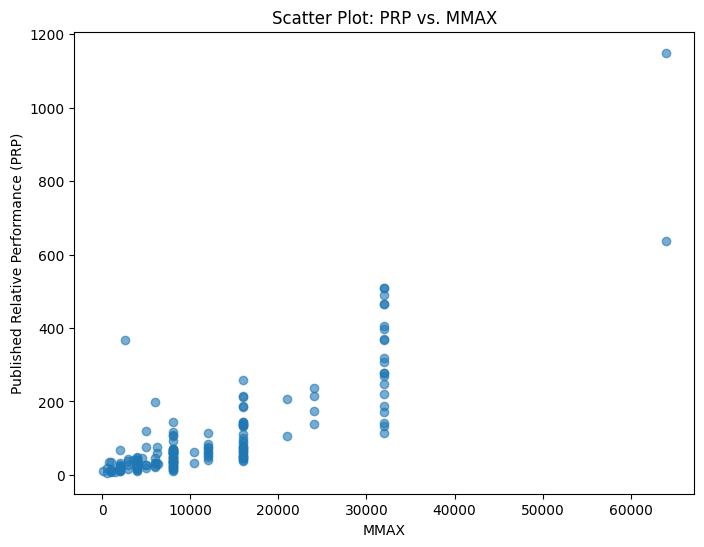

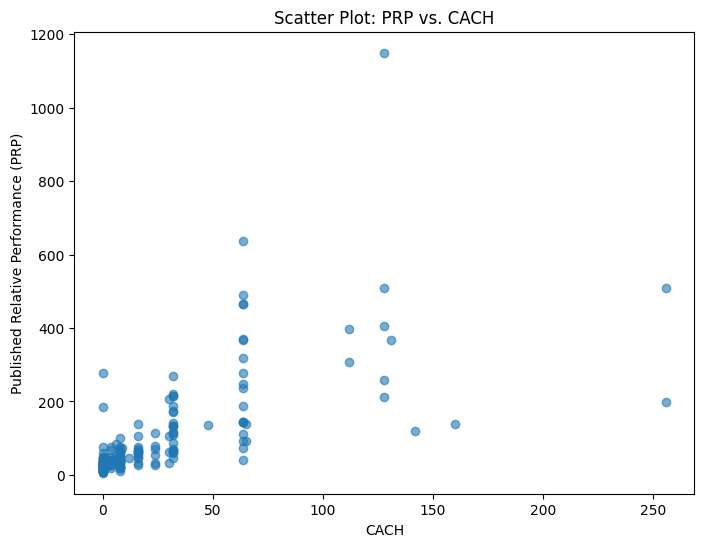

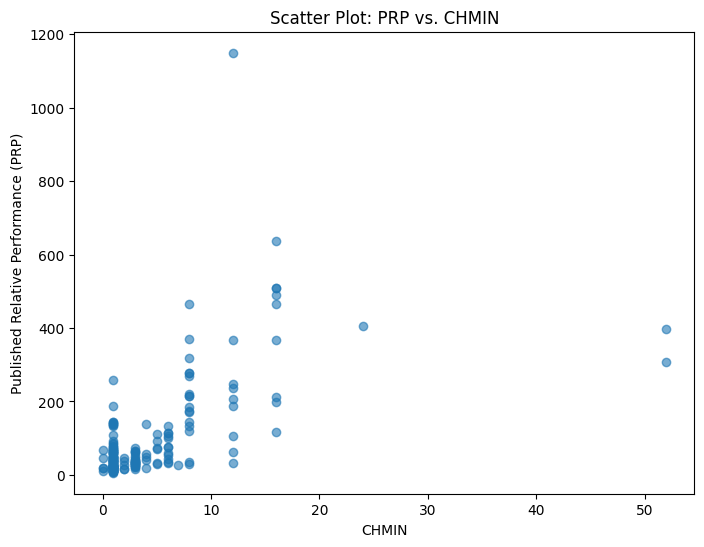

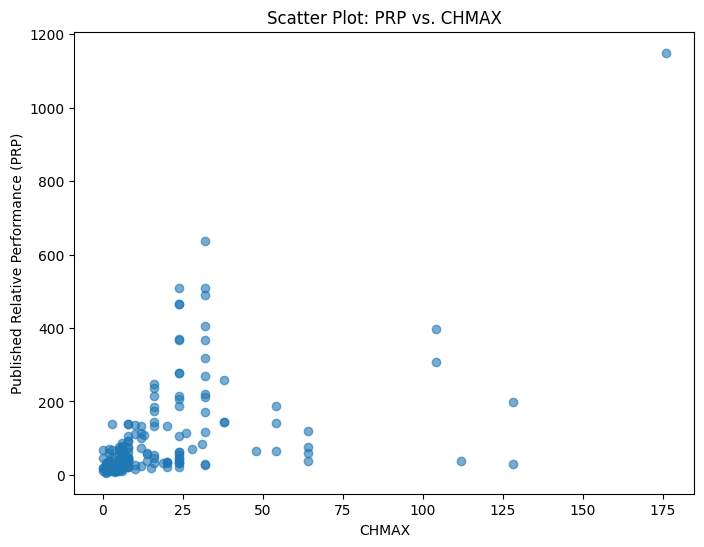

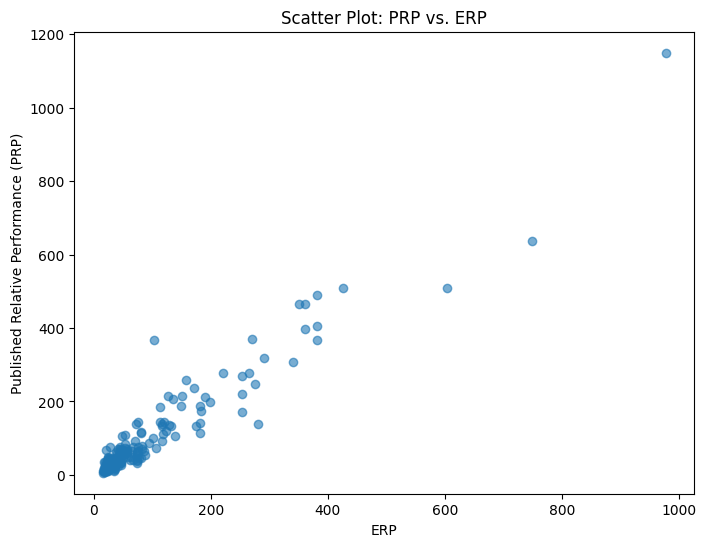

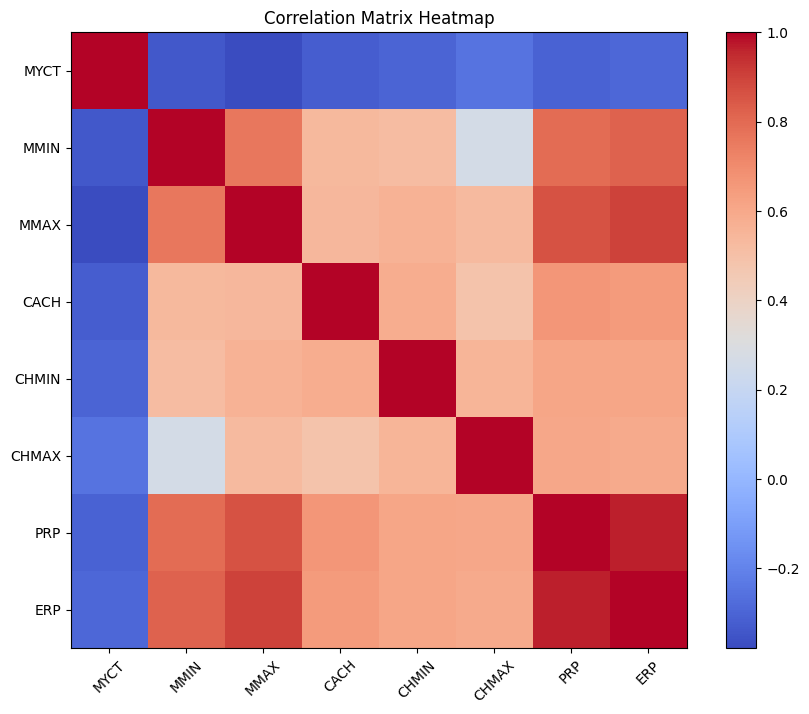

Summary Statistics:
              MYCT          MMIN          MMAX        CACH       CHMIN  \
count   209.000000    209.000000    209.000000  209.000000  209.000000   
mean    203.822967   2867.980861  11796.153110   25.205742    4.698565   
std     260.262926   3878.742758  11726.564377   40.628722    6.816274   
min      17.000000     64.000000     64.000000    0.000000    0.000000   
25%      50.000000    768.000000   4000.000000    0.000000    1.000000   
50%     110.000000   2000.000000   8000.000000    8.000000    2.000000   
75%     225.000000   4000.000000  16000.000000   32.000000    6.000000   
max    1500.000000  32000.000000  64000.000000  256.000000   52.000000   

            CHMAX          PRP          ERP  
count  209.000000   209.000000   209.000000  
mean    18.267943   105.622010    99.330144  
std     25.997318   160.830733   154.757102  
min      0.000000     6.000000    15.000000  
25%      5.000000    27.000000    28.000000  
50%      8.000000    50.000000    45.

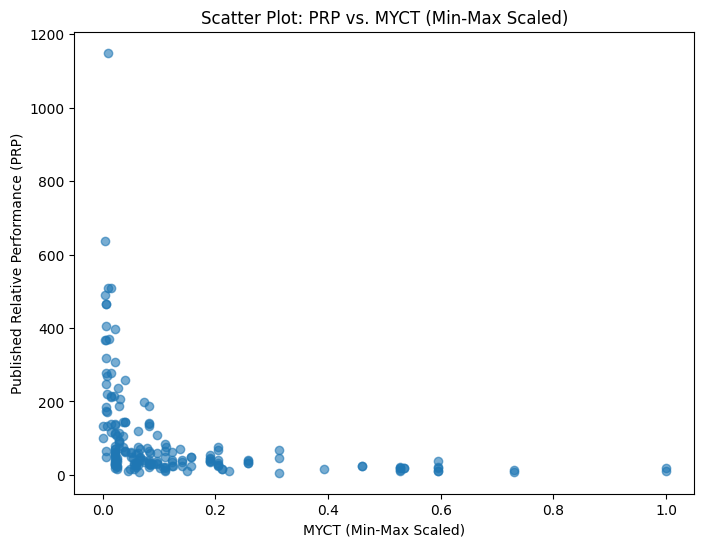

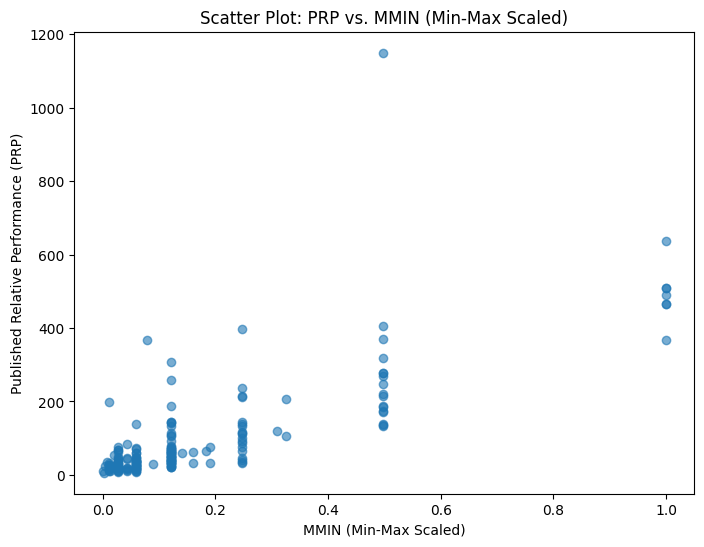

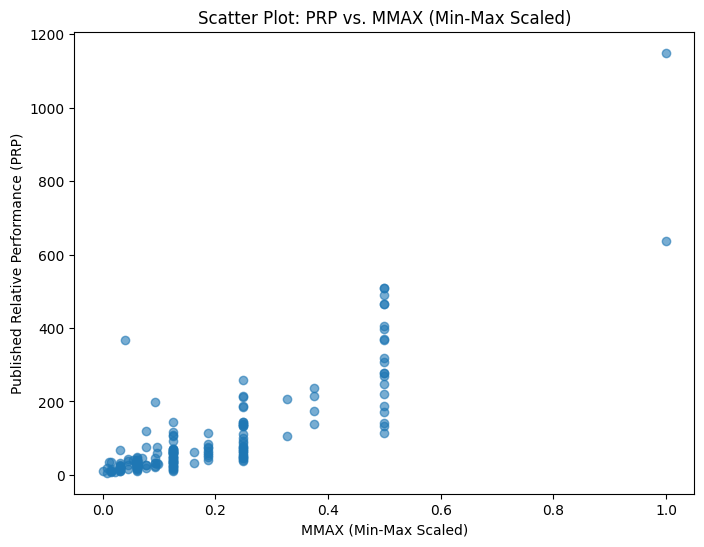

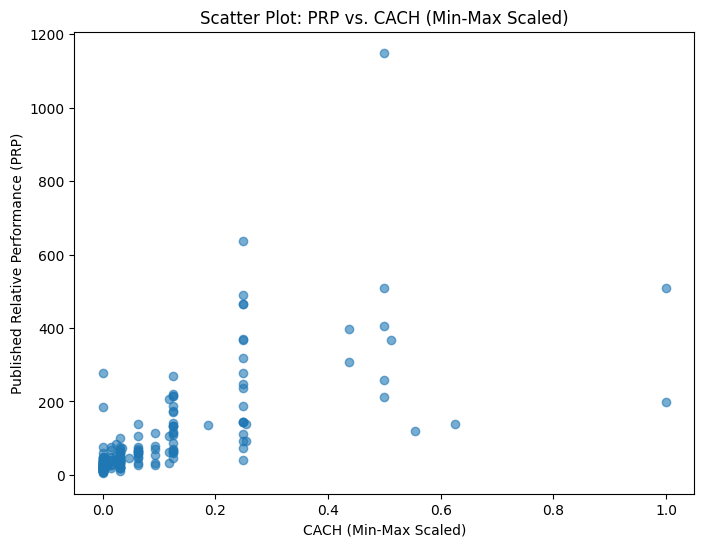

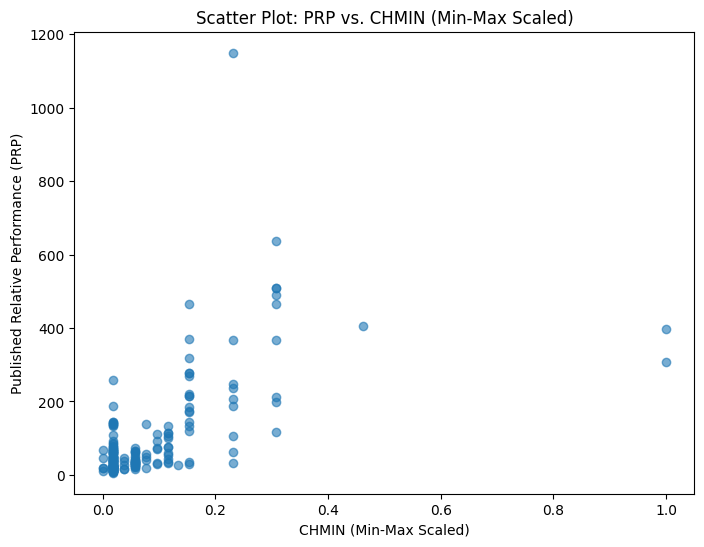

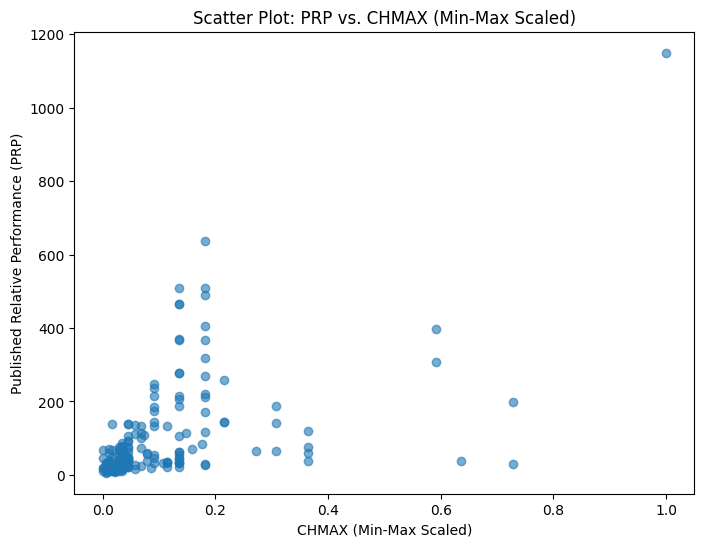

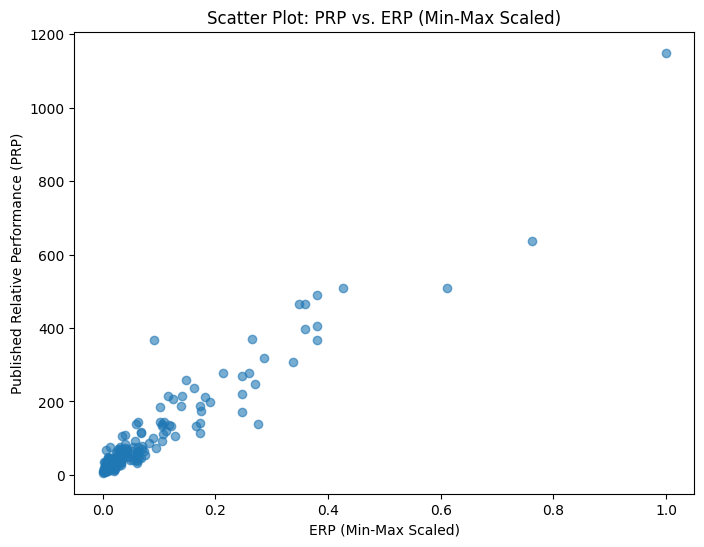

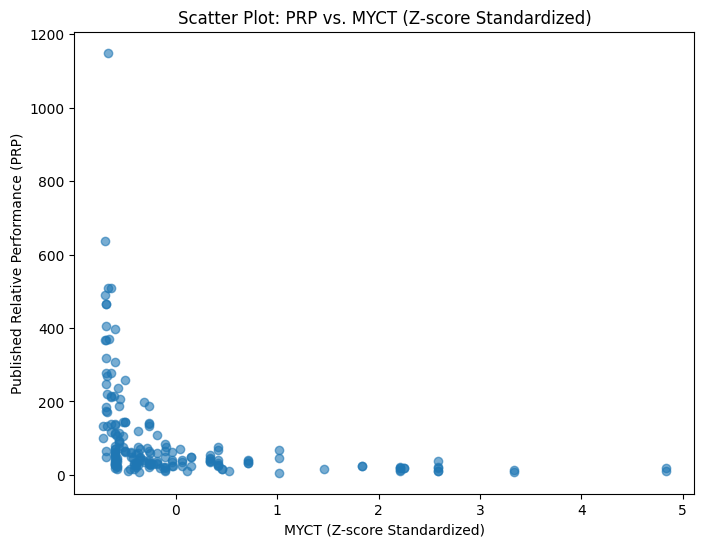

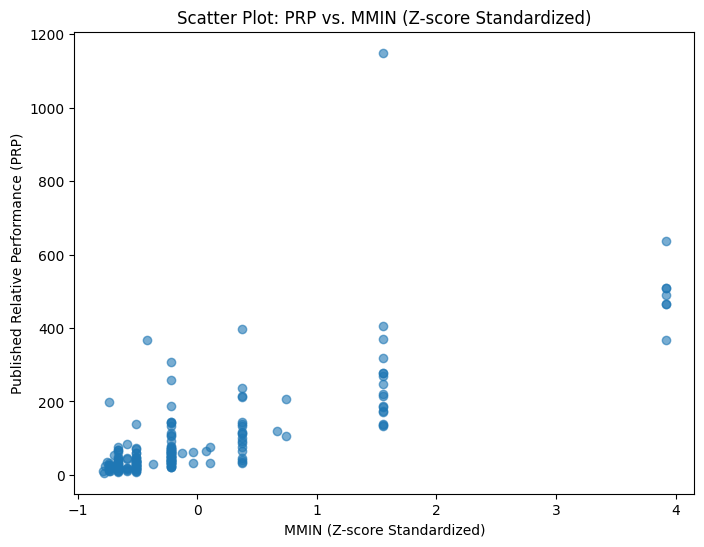

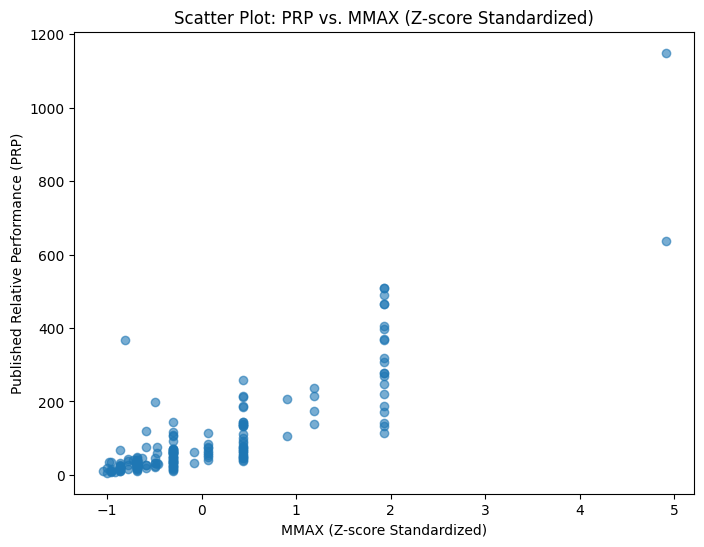

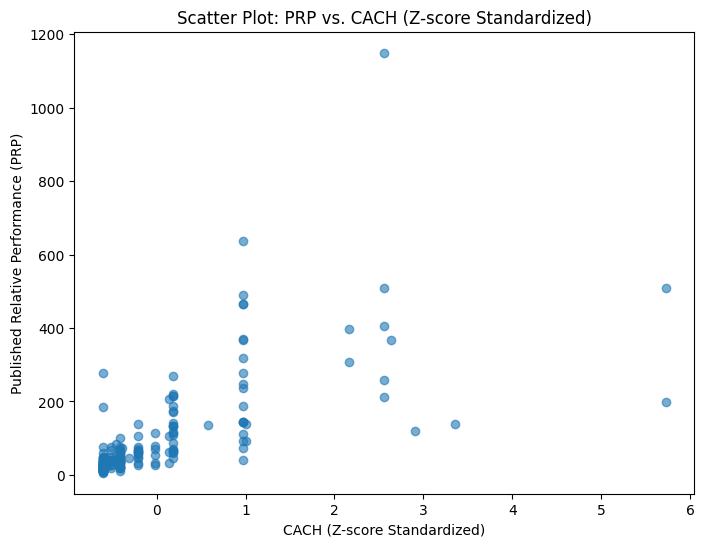

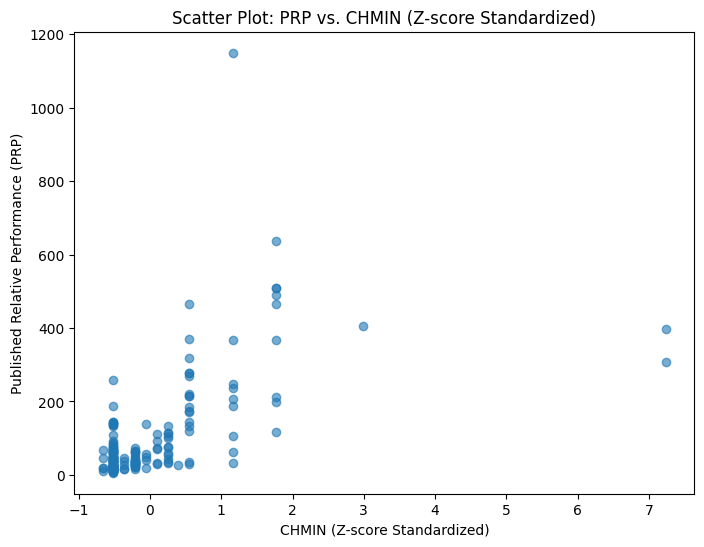

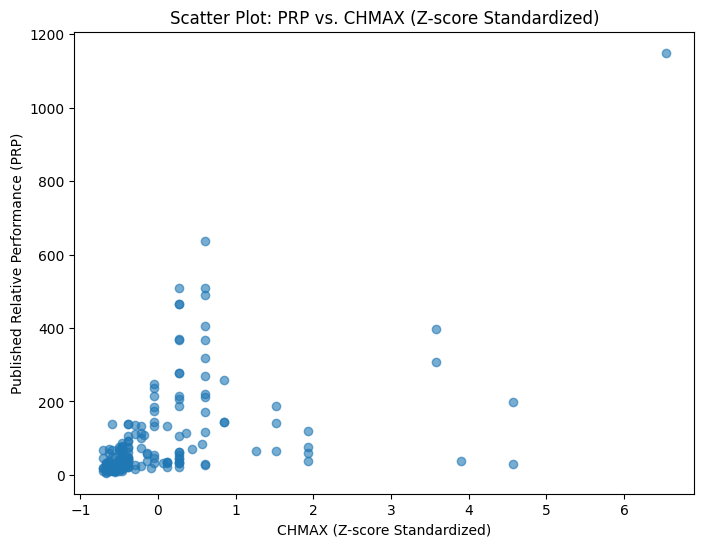

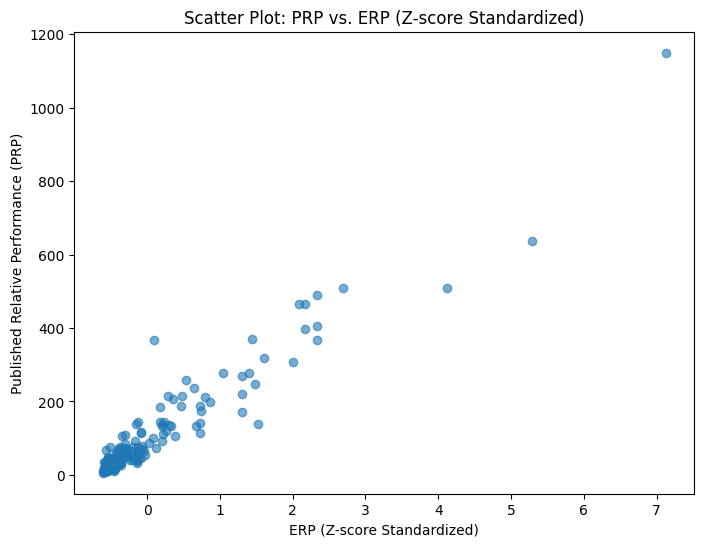

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Step 4: Split data into X (predictors) and Y (predicted)
X = df.drop(columns=['PRP'])
y = df['PRP']

# Step 5: Split data into test and train datasets (90/10 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Step 6: Train the model using Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Step 7: Scoring on the train dataset (using cross-validation)
# Perform Cross-validation with 10 folds
cv_predictions = cross_val_predict(model, X_train, y_train, cv=10)

# Calculate the MSE using the cross-validated predictions and the true target values
cv_mse = mean_squared_error(y_train, cv_predictions)

# Calculate R-squared using the cross-validated predictions and the true target values
cv_r2 = r2_score(y_train, cv_predictions)

print("Cross-Validation Mean Squared Error (MSE):", cv_mse)
print("Cross-Validation R-squared (R2) Score:", cv_r2)

# Data Visualization and Statistics
# Histogram of the target variable (PRP)
plt.figure(figsize=(8, 6))
plt.hist(y, bins=20, edgecolor='k', color='skyblue')
plt.xlabel('Published Relative Performance (PRP)')
plt.ylabel('Frequency')
plt.title('Distribution of Published Relative Performance (PRP)')
plt.show()

# Scatter plot of PRP vs. each predictor variable
for col in X_train.columns:
    plt.figure(figsize=(8, 6))
    plt.scatter(X_train[col], y_train, alpha=0.6)
    plt.xlabel(col)
    plt.ylabel('Published Relative Performance (PRP)')
    plt.title(f'Scatter Plot: PRP vs. {col}')
    plt.show()

# Correlation matrix heatmap
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(correlation_matrix)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix)), correlation_matrix.columns)
plt.title('Correlation Matrix Heatmap')
plt.show()

# Summary statistics of the dataset
summary_stats = df.describe()
print("Summary Statistics:")
print(summary_stats)

# Additional Statistics (optional)
# If you want to calculate specific statistics for the dataset, you can use numpy functions. For example:

# Mean of the PRP variable
mean_prp = np.mean(df['PRP'])
print("Mean of PRP:", mean_prp)

# Median of the PRP variable
median_prp = np.median(df['PRP'])
print("Median of PRP:", median_prp)

# Standard deviation of the PRP variable
std_prp = np.std(df['PRP'])
print("Standard Deviation of PRP:", std_prp)

# Linear Regression - Model Fitted (Min-Max Normalized Data)
# Min-Max scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit the model on scaled data
model.fit(X_train_scaled, y_train)

# Scatter plot of PRP vs. each predictor variable with Min-Max scaled data
for col in X_train.columns:
    plt.figure(figsize=(8, 6))
    plt.scatter(X_train_scaled[:, X_train.columns.get_loc(col)], y_train, alpha=0.6)
    plt.xlabel(col + ' (Min-Max Scaled)')
    plt.ylabel('Published Relative Performance (PRP)')
    plt.title(f'Scatter Plot: PRP vs. {col} (Min-Max Scaled)')
    plt.show()

# Linear Regression - Model Fitted (Z-score Standardized Data)
# Z-score standardization
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# Fit the model on standardized data
model.fit(X_train_std, y_train)

# Scatter plot of PRP vs. each predictor variable with Z-score standardized data
for col in X_train.columns:
    plt.figure(figsize=(8, 6))
    plt.scatter(X_train_std[:, X_train.columns.get_loc(col)], y_train, alpha=0.6)
    plt.xlabel(col + ' (Z-score Standardized)')
    plt.ylabel('Published Relative Performance (PRP)')
    plt.title(f'Scatter Plot: PRP vs. {col} (Z-score Standardized)')
    plt.show()


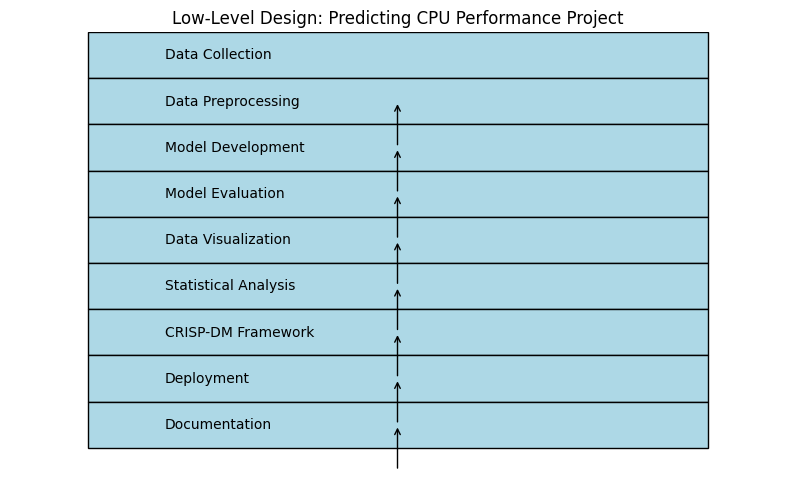

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Define stages and their positions
stages = ['Data Collection', 'Data Preprocessing', 'Model Development',
          'Model Evaluation', 'Data Visualization', 'Statistical Analysis',
          'CRISP-DM Framework', 'Deployment', 'Documentation']

# Draw rectangles for each stage
rectangles = []
for i, stage in enumerate(stages):
    rect = patches.Rectangle((0.1, 0.9 - i * 0.1), 0.8, 0.1, linewidth=1, edgecolor='black', facecolor='lightblue')
    ax.add_patch(rect)
    rectangles.append(rect)
    ax.text(0.2, 0.9 - i * 0.1 + 0.05, stage, verticalalignment='center')

# Add arrows to represent the flow
for i in range(len(stages) - 1):
    ax.annotate('', xy=(0.5, 0.85 - i * 0.1), xytext=(0.5, 0.85 - (i + 1) * 0.1),
                arrowprops=dict(arrowstyle='->', color='black'))

# Set axis properties
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Add a title
plt.title('Low-Level Design: Predicting CPU Performance Project')

# Show the diagram
plt.show()


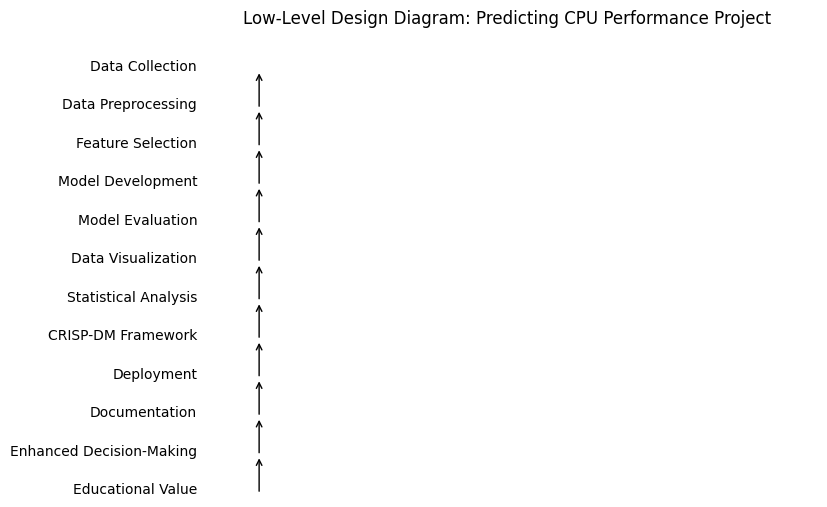

In [11]:
import matplotlib.pyplot as plt

# Define the main components of the low-level design
components = [
    "Data Collection",
    "Data Preprocessing",
    "Feature Selection",
    "Model Development",
    "Model Evaluation",
    "Data Visualization",
    "Statistical Analysis",
    "CRISP-DM Framework",
    "Deployment",
    "Documentation",
    "Enhanced Decision-Making",
    "Educational Value"
]

# Define the connections between components
connections = [
    (0, 1), (1, 2), (2, 3), (3, 4), (4, 5),
    (5, 6), (6, 7), (7, 8), (8, 9), (9, 10),
    (10, 11)
]

# Create a figure and axis for the diagram
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the components as nodes
for idx, component in enumerate(components):
    ax.annotate(component, xy=(0, -idx), fontsize=10, ha="right")

# Plot the connections between components as arrows
for connection in connections:
    start_idx, end_idx = connection
    ax.annotate("", xy=(0.1, -start_idx), xytext=(0.1, -end_idx),
                arrowprops=dict(arrowstyle="->"))

# Adjust plot settings
ax.set_xlim(0, 1)
ax.set_ylim(-len(components) + 1, 1)
ax.axis("off")

# Set a title for the diagram
plt.title("Low-Level Design Diagram: Predicting CPU Performance Project")

# Display the diagram
plt.show()


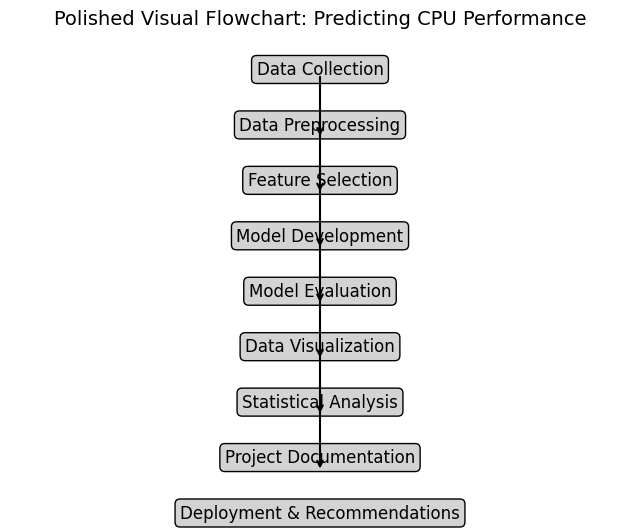

In [18]:
import matplotlib.pyplot as plt

# Define the flowchart steps
steps = [
    "Data Collection",
    "Data Preprocessing",
    "Feature Selection",
    "Model Development",
    "Model Evaluation",
    "Data Visualization",
    "Statistical Analysis",
    "Project Documentation",
    "Deployment & Recommendations"
]

# Define the flowchart connections (arrows)
connections = [
    (1, 0),
    (2, 1),
    (3, 2),
    (4, 3),
    (5, 4),
    (6, 5),
    (7, 6),
    (8, 7)
]

# Create the figure and axis for the flowchart
fig, ax = plt.subplots(figsize=(8, 6))

# Draw the flowchart
for i, step in enumerate(steps):
    ax.text(0.5, 0.92 - i * 0.12, step, ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="lightgray"))

for connection in connections:
    ax.annotate('', xy=(0.5, 0.89 - connection[0] * 0.12), xytext=(0.5, 0.91 - connection[1] * 0.12),
                arrowprops=dict(arrowstyle='->', lw=1.5))

# Adjust plot settings
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Add a title and display the flowchart
plt.title("Polished Visual Flowchart: Predicting CPU Performance", fontsize=14)
plt.show()


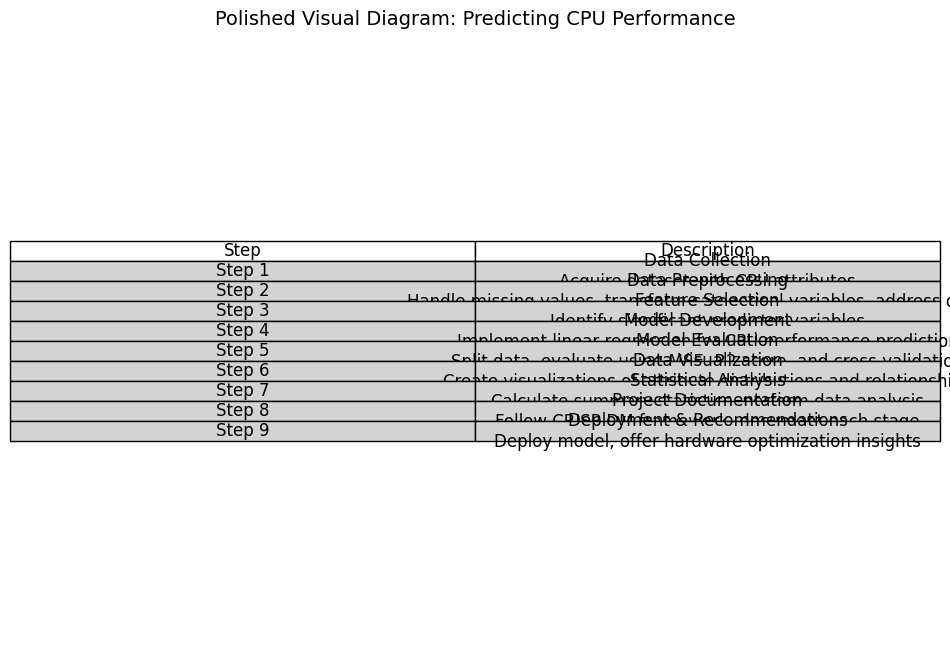

In [20]:
import matplotlib.pyplot as plt

# Define the steps and descriptions
steps = [
    ("Step 1", "Data Collection\nAcquire dataset with CPU attributes"),
    ("Step 2", "Data Preprocessing\nHandle missing values, transform categorical variables, address outliers"),
    ("Step 3", "Feature Selection\nIdentify significant predictor variables"),
    ("Step 4", "Model Development\nImplement linear regression for CPU performance prediction"),
    ("Step 5", "Model Evaluation\nSplit data, evaluate using MSE, R2 score, and cross-validation"),
    ("Step 6", "Data Visualization\nCreate visualizations of attribute distributions and relationships"),
    ("Step 7", "Statistical Analysis\nCalculate summary statistics, perform data analysis"),
    ("Step 8", "Project Documentation\nFollow CRISP-DM framework, document each stage"),
    ("Step 9", "Deployment & Recommendations\nDeploy model, offer hardware optimization insights")
]

# Create the figure and axis for the diagram
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the steps as a table
table = plt.table(cellText=steps, cellLoc='center', colLabels=['Step', 'Description'],
                  loc='center', cellColours=[['lightgray'] * 2] * len(steps))

# Adjust table settings
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Remove axes
ax.axis('off')

# Add a title
plt.title("Polished Visual Diagram: Predicting CPU Performance", fontsize=14)

# Display the diagram
plt.show()
